In [1]:
import tensorflow as tf
tf.random.set_seed(42)
import tensorflow_hub as hub
from tensorflow.keras import layers
import os
from glob import glob
import pandas as pd
import numpy as np
np.random.seed(42)
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Define the path to the Excel file
csv_file_path = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/kidneyData.csv'

# Read the Excel file into a Pandas DataFrame
df = pd.read_csv(csv_file_path)

# shuffling the dataframe
df = df.sample(frac=1, random_state=42)

In [3]:
# dropping the first unnamed column
df.drop(columns=df.columns[0], axis=1,  inplace=True)

# reaplacing path to match the kaggle dir
df['path'] = df['path'].str.replace('/content/data/','/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/')


# replacing 'space' with '-' from the path
df['path'] = df['path'].str.replace(' ','-')

# removing 'comma' from the path
df['path'] = df['path'].str.replace(',','')

# fixing naming issues
df['path'] = df['path'].str.replace('CT-KIDNEY-DATASET-Normal-CYST-TUMOR-and-STONE','CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')
df['path'] = df['path'].str.replace('-(',' (')

df['path'] = df['path'].str.replace('TUMOR','Tumor')
df['path'] = df['path'].str.replace('NORMAL','Normal')
df['path'] = df['path'].str.replace('STONE','Stone')
df['path'] = df['path'].str.replace('CYST','Cyst')


# Drop the 'diag', 'target' column
df = df.drop(columns=['image_id','diag','target'])

df.head(3)

,path,Class
396,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Tumor
247,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Tumor
9256,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst


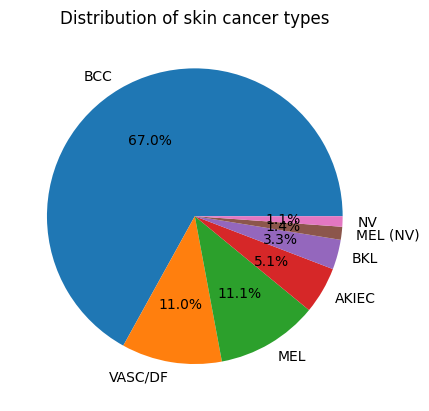

In [4]:
import matplotlib.pyplot as plt

# Data (percentages)
data = [66.95, 10.97, 11.11, 5.13, 3.26, 1.42, 1.14]
labels = ['BCC', 'VASC/DF', 'MEL', 'AKIEC', 'BKL', 'MEL (NV)', 'NV']

# Create the pie chart
plt.pie(data, labels=labels, autopct="%1.1f%%")
plt.title('Distribution of skin cancer types')
plt.show()


In [ ]:
# Assuming your DataFrame is called 'df'
class_counts = df['Class'].value_counts().sort_values(ascending=False)  # Count class occurrences

# Separate data and labels for the pie chart
class_labels = class_counts.index.to_numpy()
class_values = class_counts.to_numpy()


import plotly.express as px
import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go

fig = px.pie(data, values='Count', names='Class', title='Data Distribution', 
             labels={'Count': 'Count'},  # Add count labels to the chart
             hover_data={'Count': ':.2f'},  # Display count with 2 decimal places on hover
             hole=0.3)  # Adjust the size of the hole in the center

# Adding count and percentage to each sector
fig.update_traces(textinfo='percent+label+value', pull=[0.1 if i % 2 == 0 else 0 for i in range(len(data))])

config = {
  'toImageButtonOptions': {
    'format': 'svg', # one of png, svg, jpeg, webp
    'filename': 'custom_image',
    'height': 500,
    'width': 500,
    'scale': 1 # Multiply title/legend/axis/canvas sizes by this factor
  }
}

fig.show(config=config)

In [6]:
# Get unique classes
unique_classes = df['Class'].unique()

unique_classes

array(['Tumor', 'Cyst', 'Normal', 'Stone'], dtype=object)

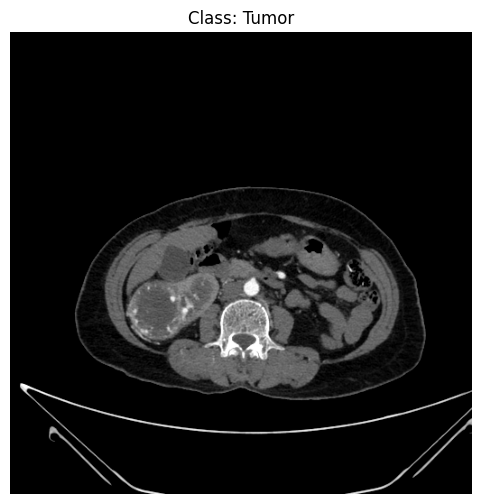

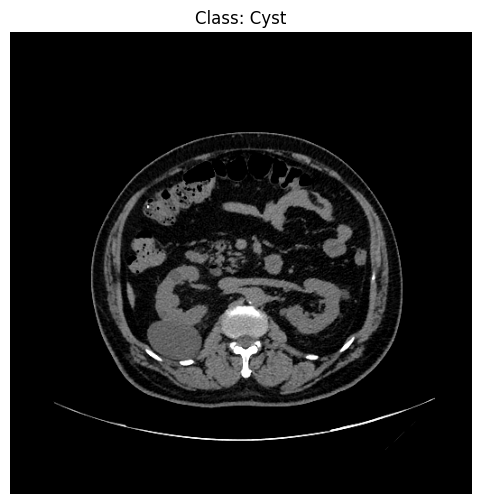

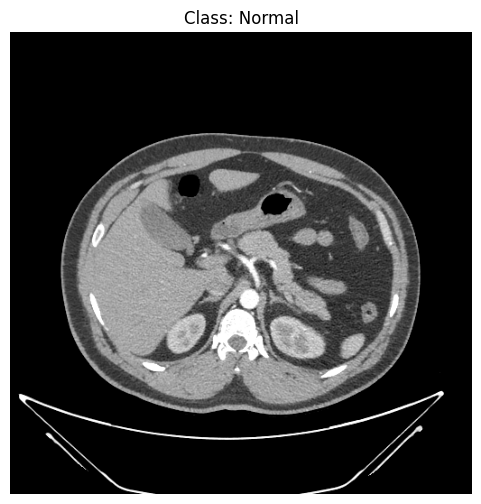

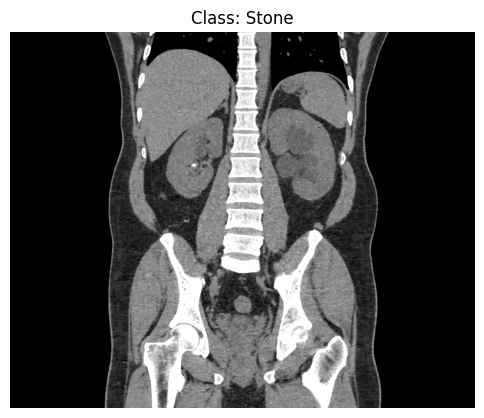

In [7]:
# Plot one representative image for each unique class
for cls in unique_classes:
    class_df = df[df['Class'] == cls]
    sample_row = class_df.iloc[0]  # Select the first row as a representative sample
    img = Image.open(sample_row['path'])
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Class: {sample_row['Class']}")
    plt.axis('off')
    plt.show()

In [8]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of the ImageDataGenerator class with the desired augmentations
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, # rotation
    zoom_range=0.2, # zoom
    horizontal_flip=True, # horizontal flip
    vertical_flip=True, # vertical flip
    width_shift_range=0.1, # horizontal shift
    height_shift_range=0.1, # vertical shift
    fill_mode='nearest', # fill mode for any new pixels created during augmentation
)

In [9]:
# Split the data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Get the number of classes
num_classes = len(unique_classes)

# Convert cell types to numeric labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['Class'])
test_labels = label_encoder.transform(test_df['Class'])

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels, num_classes=num_classes)
test_labels = to_categorical(test_labels, num_classes=num_classes)

# Setting image size
image_size = (224, 224, 3)

# Setting batch size
batch_size = 32

# Create a flow for the training set
train_dataset = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='Class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Create a flow for the testing set
val_dataset = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='Class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 9956 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


In [9]:
# Setting img size
IMG_SIZE = 224

# Setting input shape to the model
INPUT_SHAPE = [IMG_SIZE, IMG_SIZE, 3]

NUM_OF_LABELS = len(unique_classes)

NUM_EPOCHS = 50 #An epoch means training the neural network with all the training data for one cycle

# Importing model url
efficientnetV2_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet21k_ft1k_l/classification/2"
inceptionnetV2_url = "https://tfhub.dev/google/imagenet/inception_v2/classification/5"
mobilenetV2_url = "https://www.kaggle.com/models/google/mobilenet-v2/frameworks/TensorFlow2/variations/035-224-classification/versions/2"
vit_b16_url = "/kaggle/input/vision-transformer/tensorflow2/vit-b16-classification/1"

In [9]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# def create_custom_cnn_model():
#     model = Sequential()
    
#     # Convolutional layers
#     model.add(Conv2D(32, (3, 3), activation='relu', input_shape=INPUT_SHAPE))
#     model.add(MaxPooling2D((2, 2)))
    
#     model.add(Conv2D(64, (3, 3), activation='relu'))
#     model.add(MaxPooling2D((2, 2)))
    
#     model.add(Conv2D(128, (3, 3), activation='relu'))
#     model.add(MaxPooling2D((2, 2)))
    
#     # Flatten layer
#     model.add(Flatten())
    
#     # Dense layers
#     model.add(Dense(512, activation='relu'))
#     model.add(Dropout(0.5))
    
#     model.add(Dense(NUM_OF_LABELS, activation='softmax'))
    
#     # Compile the model
#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
#     return model


# # Use the custom CNN model in the train_model function
# def train_custom_cnn_model():
#     model = create_custom_cnn_model()

#     # Fit the model to the data passing it the callbacks we created
#     history = model.fit(x=train_dataset,
#                         epochs=NUM_EPOCHS,
#                         validation_data=val_dataset,
#                         validation_freq=1,
#                         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])

#     # Return the fitted model
#     return model, history

In [10]:
# Create a function which builds a Keras model

def create_model(model_url):

    # Download the pretrained model and save it as a Keras layer
    feature_extractor_layer = hub.KerasLayer(model_url, trainable=False, name="feature_extraction_layer", input_shape=INPUT_SHAPE)

    # Create model
    model = tf.keras.Sequential([
        feature_extractor_layer,
        layers.Dense(NUM_OF_LABELS, activation="softmax", name="output-layer")
    ])
    # Compile the model
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"]
    )

    return model

In [11]:

# Build a function to train and return a trained model
def train_model(model_url, model_name):

    # Create a model
    model = create_model(model_url)

    # Fit the model to the data passing it the callbacks we created
    history = model.fit(x=train_dataset,
        epochs=NUM_EPOCHS,
        validation_data=val_dataset,
        validation_freq=1,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])

    # Return the fitted model
    return model,history

In [12]:
# custom_cnn_model, custom_cnn_history = train_custom_cnn_model()

In [13]:
# custom_cnn_model.save("/kaggle/working/custom_cnn_model")

In [14]:
efficientnetV2_model, efficientnetV2_history = train_model(efficientnetV2_url, "efficientnetV2")

Epoch 1/50
312/312 [==============================] - 274s 790ms/step - loss: 0.8123 - accuracy: 0.6913 - val_loss: 0.6182 - val_accuracy: 0.7526
Epoch 2/50
312/312 [==============================] - 182s 583ms/step - loss: 0.5520 - accuracy: 0.7928 - val_loss: 0.4889 - val_accuracy: 0.8225
Epoch 3/50
312/312 [==============================] - 179s 573ms/step - loss: 0.4833 - accuracy: 0.8201 - val_loss: 0.4635 - val_accuracy: 0.8257
Epoch 4/50
312/312 [==============================] - 175s 560ms/step - loss: 0.4389 - accuracy: 0.8392 - val_loss: 0.4350 - val_accuracy: 0.8418
Epoch 5/50
312/312 [==============================] - 178s 571ms/step - loss: 0.4169 - accuracy: 0.8416 - val_loss: 0.4419 - val_accuracy: 0.8365
Epoch 6/50
312/312 [==============================] - 179s 575ms/step - loss: 0.4070 - accuracy: 0.8461 - val_loss: 0.4495 - val_accuracy: 0.8333
Epoch 7/50
312/312 [==============================] - 181s 579ms/step - loss: 0.3920 - accuracy: 0.8545 - val_loss: 0.4183 -

In [15]:
efficientnetV2_model.save("/kaggle/working/efficientnetV2")

In [16]:
!zip -r efficientnetV2.zip /kaggle/working/efficientnetV2

  adding: kaggle/working/efficientnetV2/ (stored 0%)
  adding: kaggle/working/efficientnetV2/assets/ (stored 0%)
  adding: kaggle/working/efficientnetV2/variables/ (stored 0%)
  adding: kaggle/working/efficientnetV2/variables/variables.index (deflated 83%)
  adding: kaggle/working/efficientnetV2/variables/variables.data-00000-of-00001 (deflated 6%)
  adding: kaggle/working/efficientnetV2/saved_model.pb (deflated 92%)
  adding: kaggle/working/efficientnetV2/keras_metadata.pb (deflated 81%)
  adding: kaggle/working/efficientnetV2/fingerprint.pb (stored 0%)


In [17]:
inceptionnetV2_model, inceptionnetV2_history = train_model(inceptionnetV2_url, "inceptionnetV2")

Epoch 1/50
312/312 [==============================] - 177s 553ms/step - loss: 0.8101 - accuracy: 0.6871 - val_loss: 0.5838 - val_accuracy: 0.7795
Epoch 2/50
312/312 [==============================] - 172s 551ms/step - loss: 0.5857 - accuracy: 0.7690 - val_loss: 0.5137 - val_accuracy: 0.8028
Epoch 3/50
312/312 [==============================] - 174s 559ms/step - loss: 0.5391 - accuracy: 0.7948 - val_loss: 0.5316 - val_accuracy: 0.7819
Epoch 4/50
312/312 [==============================] - 170s 544ms/step - loss: 0.5103 - accuracy: 0.8051 - val_loss: 0.4867 - val_accuracy: 0.8177
Epoch 5/50
312/312 [==============================] - 170s 546ms/step - loss: 0.4750 - accuracy: 0.8123 - val_loss: 0.4774 - val_accuracy: 0.8092
Epoch 6/50
312/312 [==============================] - 169s 541ms/step - loss: 0.4800 - accuracy: 0.8134 - val_loss: 0.4602 - val_accuracy: 0.8193
Epoch 7/50
312/312 [==============================] - 170s 545ms/step - loss: 0.4711 - accuracy: 0.8209 - val_loss: 0.4566 -

In [ ]:
inceptionnetV2_model.save("/kaggle/working/inceptionnetV2")

In [19]:
!zip -r inceptionnetV2.zip /kaggle/working/inceptionnetV2

  adding: kaggle/working/inceptionnetV2/ (stored 0%)
  adding: kaggle/working/inceptionnetV2/assets/ (stored 0%)
  adding: kaggle/working/inceptionnetV2/variables/ (stored 0%)
  adding: kaggle/working/inceptionnetV2/variables/variables.index (deflated 80%)
  adding: kaggle/working/inceptionnetV2/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: kaggle/working/inceptionnetV2/saved_model.pb (deflated 93%)
  adding: kaggle/working/inceptionnetV2/keras_metadata.pb (deflated 81%)
  adding: kaggle/working/inceptionnetV2/fingerprint.pb (stored 0%)


In [24]:
mobilenetV2_model, mobilenetV2_history = train_model(mobilenetV2_url, "mobilenetV2")

Epoch 1/50
312/312 [==============================] - 173s 543ms/step - loss: 0.7723 - accuracy: 0.7083 - val_loss: 0.6189 - val_accuracy: 0.7663
Epoch 2/50
312/312 [==============================] - 169s 541ms/step - loss: 0.5148 - accuracy: 0.8038 - val_loss: 0.4845 - val_accuracy: 0.8173
Epoch 3/50
312/312 [==============================] - 169s 542ms/step - loss: 0.4585 - accuracy: 0.8319 - val_loss: 0.4315 - val_accuracy: 0.8305
Epoch 4/50
312/312 [==============================] - 171s 548ms/step - loss: 0.4252 - accuracy: 0.8394 - val_loss: 0.4257 - val_accuracy: 0.8269
Epoch 5/50
312/312 [==============================] - 167s 535ms/step - loss: 0.4000 - accuracy: 0.8497 - val_loss: 0.4018 - val_accuracy: 0.8418
Epoch 6/50
312/312 [==============================] - 168s 540ms/step - loss: 0.3911 - accuracy: 0.8521 - val_loss: 0.3607 - val_accuracy: 0.8699
Epoch 7/50
312/312 [==============================] - 168s 538ms/step - loss: 0.3618 - accuracy: 0.8606 - val_loss: 0.3607 -

In [25]:
mobilenetV2_model.save("/kaggle/working/mobilenetV2")

In [26]:
!zip -r mobilenetV2.zip /kaggle/working/mobilenetV2

  adding: kaggle/working/mobilenetV2/ (stored 0%)
  adding: kaggle/working/mobilenetV2/assets/ (stored 0%)
  adding: kaggle/working/mobilenetV2/variables/ (stored 0%)
  adding: kaggle/working/mobilenetV2/variables/variables.index (deflated 78%)
  adding: kaggle/working/mobilenetV2/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: kaggle/working/mobilenetV2/saved_model.pb (deflated 92%)
  adding: kaggle/working/mobilenetV2/keras_metadata.pb (deflated 81%)
  adding: kaggle/working/mobilenetV2/fingerprint.pb (stored 0%)


In [12]:
vit_b16_model, vit_b16_history = train_model(vit_b16_url, "ViT-B16")

Epoch 1/50
312/312 [==============================] - 353s 1s/step - loss: 0.8466 - accuracy: 0.6747 - val_loss: 0.5843 - val_accuracy: 0.7723
Epoch 2/50
312/312 [==============================] - 243s 778ms/step - loss: 0.5240 - accuracy: 0.8084 - val_loss: 0.4626 - val_accuracy: 0.8382
Epoch 3/50
312/312 [==============================] - 245s 785ms/step - loss: 0.4550 - accuracy: 0.8329 - val_loss: 0.4356 - val_accuracy: 0.8297
Epoch 4/50
312/312 [==============================] - 241s 772ms/step - loss: 0.4104 - accuracy: 0.8477 - val_loss: 0.4439 - val_accuracy: 0.8321
Epoch 5/50
312/312 [==============================] - 236s 757ms/step - loss: 0.3819 - accuracy: 0.8623 - val_loss: 0.4003 - val_accuracy: 0.8498
Epoch 6/50
312/312 [==============================] - 243s 779ms/step - loss: 0.3655 - accuracy: 0.8673 - val_loss: 0.3204 - val_accuracy: 0.8791
Epoch 7/50
312/312 [==============================] - 249s 797ms/step - loss: 0.3372 - accuracy: 0.8776 - val_loss: 0.3294 - va

In [14]:
vit_b16_model.save("/kaggle/working/vit_b16")

In [15]:
!zip -r vit_b16.zip /kaggle/working/vit_b16

  adding: kaggle/working/vit_b16/ (stored 0%)
  adding: kaggle/working/vit_b16/saved_model.pb (deflated 91%)
  adding: kaggle/working/vit_b16/keras_metadata.pb (deflated 81%)
  adding: kaggle/working/vit_b16/variables/ (stored 0%)
  adding: kaggle/working/vit_b16/variables/variables.index (deflated 75%)
  adding: kaggle/working/vit_b16/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: kaggle/working/vit_b16/assets/ (stored 0%)
  adding: kaggle/working/vit_b16/fingerprint.pb (stored 0%)


In [ ]:
import matplotlib.pyplot as plt

# Function to plot and save accuracy and loss curves
def plot_and_save_curves(history, model_name):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Training', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'], loc='upper left')

    # Save the plots
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/Evaluation/AccuracyLoss/{model_name}_curves.png')
    plt.show()


In [ ]:
# Initializing Directory
os.makedirs('/kaggle/working/Evaluation/AccuracyLoss')

# Plot and save curves for custom CNN model
# plot_and_save_curves(custom_cnn_history, "CustomCNN")

# Plot and save curves for EfficientNetV2 model
plot_and_save_curves(efficientnetV2_history, "EfficientNetV2")

# Plot and save curves for EfficientNetV2 model
plot_and_save_curves(inceptionnetV2_history, "InceptionNetV2")

# Plot and save curves for EfficientNetV2 model
plot_and_save_curves(mobilenetV2_history, "MobileNetV2")

# Plot and save curves for EfficientNetV2 model
plot_and_save_curves(vit_b16_history, "ViT-B16")

In [10]:
# Initialize empty lists for images and labels
images_list = []
labels_list = []

# Loop through the dataset and extract images and labels from each batch
for batch in val_dataset:
    images = batch[0]
    labels = batch[1]
    images_list.append(images)
    labels_list.append(labels)

    # Break the loop if all batches have been processed
    if len(images_list) * 32 >= val_dataset.samples:
        break

# Concatenate the lists to get the final arrays
test_images = np.concatenate(images_list, axis=0)
test_labels = np.concatenate(labels_list, axis=0)

# Print the shape of the arrays
print("Images shape:", test_images.shape)
print("Labels shape:", test_labels.shape)

Images shape: (2490, 224, 224, 3)
Labels shape: (2490, 4)


In [20]:
def plot_confusion_matrix(model, predictions, predicted_labels, true_labels, save_path):
    # Compute the confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    classes = unique_labels(true_labels, predicted_labels)
    # Plot the confusion matrix
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=f'Confusion Matrix for {model_name}',
           ylabel='True label',
           xlabel='Predicted label')

    # Loop over data dimensions and create text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    # Save the plot as an image file
    file_name = f'{model_name}_cm.png'
    file_path = os.path.join(save_path, file_name)
    plt.savefig(file_path)

    plt.show()

def plot_roc(model, predictions, predicted_labels, true_labels, save_path):

    predicted_labels = label_binarize(np.argmax(predictions, axis=1), classes=np.arange(len(unique_classes)))

    # Convert true labels to one-hot encoded format
    true_labels = label_binarize(test_labels, classes=np.arange(len(unique_classes)))

    # Compute the ROC curve and AUC score for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(true_labels[:, i], predicted_labels[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot the ROC curves
    plt.figure()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'purple', 'green', 'red', 'brown'])
    for i, color in zip(range(len(unique_classes)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve class {i} (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc="lower right")

    # Save the plot as an image file
    file_name = f'{model_name}_roc.png'
    file_path = os.path.join(save_path, file_name)
    plt.savefig(file_path)

    plt.show()


def plot_precision_recall(model, predictions, predicted_labels, true_labels, save_path):

    # Convert true labels to one-hot encoded format
    true_labels = label_binarize(test_labels, classes=np.arange(len(unique_classes)))

    # Compute the precision-recall curve and average precision score for each class
    precision = dict()
    recall = dict()
    average_precision = dict()
    for i in range(len(unique_classes)):
        precision[i], recall[i], _ = precision_recall_curve(true_labels[:, i], predictions[:, i])
        average_precision[i] = average_precision_score(true_labels[:, i], predictions[:, i])

    # Plot the precision-recall curves
    plt.figure()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'purple', 'green', 'red', 'brown'])
    for i, color in zip(range(len(unique_classes)), colors):
        plt.plot(recall[i], precision[i], color=color, lw=2, label=f'Precision-Recall curve class {i} (AP = {average_precision[i]:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')  # Move legend to top right

    # Save the plot as an image file
    file_name = f'{model_name}_precision_recall.png'
    file_path = os.path.join(save_path, file_name)
    plt.savefig(file_path, bbox_inches='tight')  # Save with tight layout

    plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

def plot_classification_report(model_name, predictions, test_labels, save_path):

    # Convert predictions to class labels
    predicted_labels = np.argmax(predictions, axis=1)

    # Define the class names for your specific dataset
    class_names = unique_classes

    # Compute the classification report
    report = classification_report(test_labels, predicted_labels, target_names=class_names, output_dict=True)

    # Convert the report to a DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Drop the 'support' column
    report_df.drop('support', axis=1, inplace=True)

    # Plot the classification report
    plt.figure(figsize=(10, 5))
    sns.heatmap(report_df.drop(['accuracy', 'macro avg', 'weighted avg'], axis=0), annot=True, cmap='Blues')
    plt.title(f'Classification Report for {model_name}')
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'{model_name}_classification_report.png'))
    plt.show()

    # Print the classification report to the console
    print(f'Classification Report for {model_name}:')
    print(classification_report(test_labels, predicted_labels, target_names=class_names))

In [12]:
os.makedirs('/kaggle/working/Evaluation/ROC')
os.makedirs('/kaggle/working/Evaluation/CM')
os.makedirs('/kaggle/working/Evaluation/precision_recall')
os.makedirs('/kaggle/working/Evaluation/classification_report')

78/78 [==============================] - 23s 235ms/step


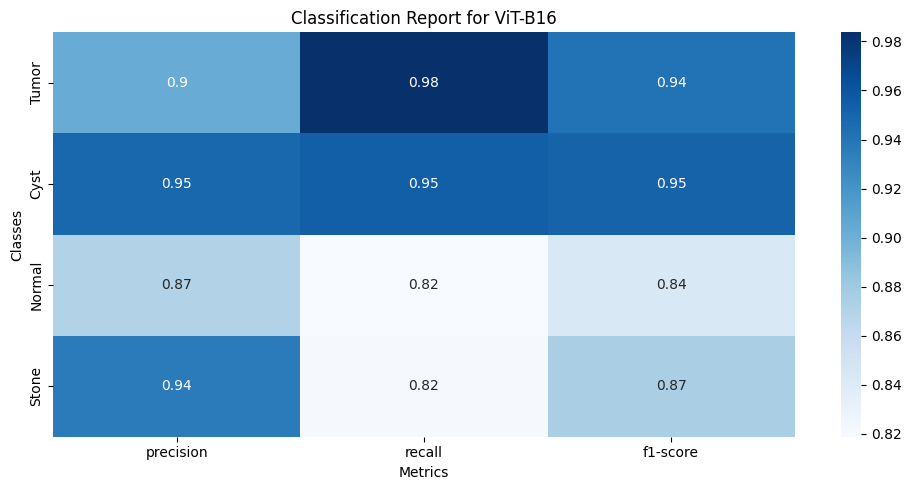

Classification Report for ViT-B16:
              precision    recall  f1-score   support

       Tumor       0.90      0.98      0.94       737
        Cyst       0.95      0.95      0.95      1019
      Normal       0.87      0.82      0.84       287
       Stone       0.94      0.82      0.87       447

    accuracy                           0.92      2490
   macro avg       0.91      0.89      0.90      2490
weighted avg       0.92      0.92      0.92      2490

78/78 [==============================] - 19s 208ms/step


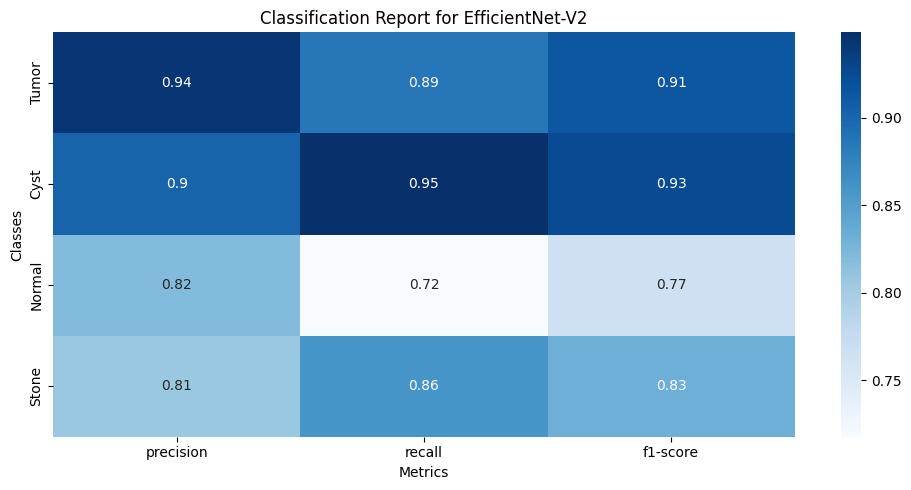

Classification Report for EfficientNet-V2:
              precision    recall  f1-score   support

       Tumor       0.94      0.89      0.91       737
        Cyst       0.90      0.95      0.93      1019
      Normal       0.82      0.72      0.77       287
       Stone       0.81      0.86      0.83       447

    accuracy                           0.89      2490
   macro avg       0.87      0.85      0.86      2490
weighted avg       0.89      0.89      0.89      2490

78/78 [==============================] - 2s 16ms/step


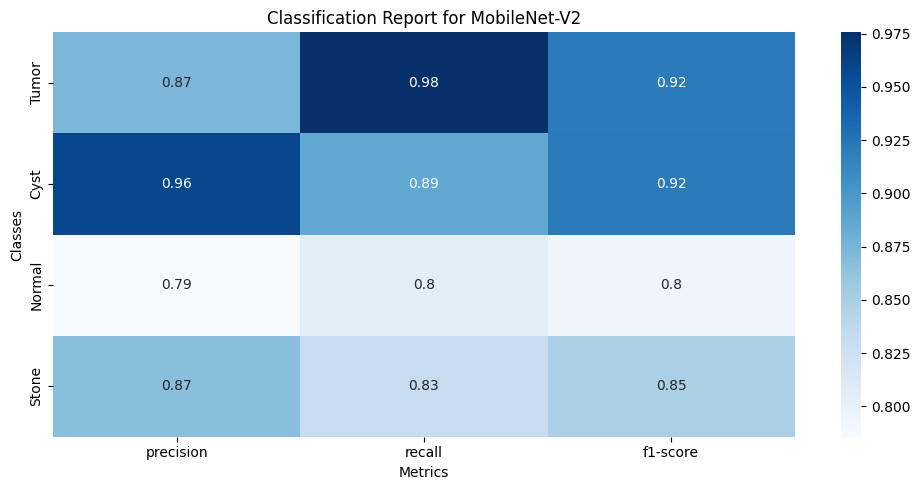

Classification Report for MobileNet-V2:
              precision    recall  f1-score   support

       Tumor       0.87      0.98      0.92       737
        Cyst       0.96      0.89      0.92      1019
      Normal       0.79      0.80      0.80       287
       Stone       0.87      0.83      0.85       447

    accuracy                           0.89      2490
   macro avg       0.87      0.87      0.87      2490
weighted avg       0.90      0.89      0.89      2490

78/78 [==============================] - 3s 35ms/step


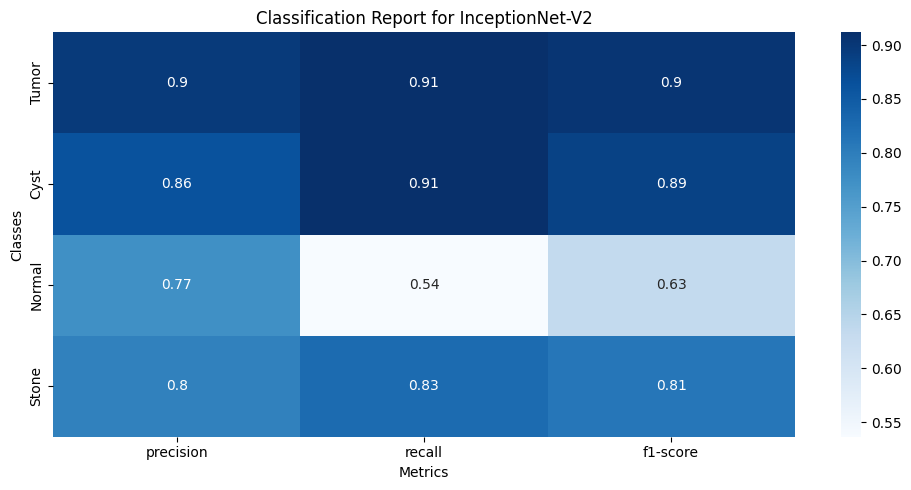

Classification Report for InceptionNet-V2:
              precision    recall  f1-score   support

       Tumor       0.90      0.91      0.90       737
        Cyst       0.86      0.91      0.89      1019
      Normal       0.77      0.54      0.63       287
       Stone       0.80      0.83      0.81       447

    accuracy                           0.85      2490
   macro avg       0.83      0.80      0.81      2490
weighted avg       0.85      0.85      0.85      2490



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
import os
import io
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from itertools import cycle
from sklearn.utils.multiclass import unique_labels

save_path_roc = "/kaggle/working/Evaluation/ROC"
save_path_cm = "/kaggle/working/Evaluation/CM"
save_path_precision_recall = "/kaggle/working/Evaluation/precision_recall"
save_path_classification_report = "/kaggle/working/Evaluation/classification_report"


# Define the models and their paths
models = {
    'ViT-B16': '/kaggle/input/ct-kidney-models/vit_b16/vit_b16',
    'EfficientNet-V2': '/kaggle/input/ct-kidney-models/efficientnetV2/efficientnetV2',
    'MobileNet-V2': '/kaggle/input/ct-kidney-models/mobilenetV2/mobilenetV2',
    'InceptionNet-V2': '/kaggle/input/ct-kidney-models/inceptionnetV2/inceptionnetV2'
}


# Loop through the models
for model_name, model_path in models.items():
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Generate predictions using the test_images
    predictions = model.predict(test_images)
    # Convert predictions to one-hot encoded format
    predicted_labels = np.argmax(predictions, axis=1)
    # Convert true labels to one-hot encoded format
    true_labels = np.argmax(test_labels, axis=1)

#     plot_confusion_matrix(model, predictions, predicted_labels, true_labels, save_path_cm)
#     plot_roc(model, predictions, predicted_labels, true_labels, save_path_roc)
#     plot_precision_recall(model, predictions, predicted_labels, true_labels, save_path_precision_recall)
    plot_classification_report(model_name, predictions, true_labels, save_path_classification_report)

In [22]:
!zip -r evaluation.zip /kaggle/working/Evaluation/classification_report

updating: kaggle/working/Evaluation/classification_report/ (stored 0%)
updating: kaggle/working/Evaluation/classification_report/EfficientNet-V2_classification_report.xlsx (deflated 11%)
updating: kaggle/working/Evaluation/classification_report/InceptionNet-V2_classification_report.xlsx (deflated 11%)
updating: kaggle/working/Evaluation/classification_report/ViT-B16_classification_report.xlsx (deflated 11%)
updating: kaggle/working/Evaluation/classification_report/MobileNet-V2_classification_report.xlsx (deflated 11%)
  adding: kaggle/working/Evaluation/classification_report/ViT-B16_classification_report.png (deflated 13%)
  adding: kaggle/working/Evaluation/classification_report/MobileNet-V2_classification_report.png (deflated 12%)
  adding: kaggle/working/Evaluation/classification_report/EfficientNet-V2_classification_report.png (deflated 12%)
  adding: kaggle/working/Evaluation/classification_report/InceptionNet-V2_classification_report.png (deflated 12%)


In [ ]:
for i in range(len(unique_classes)):
    print(f'{i} : {unique_classes[i]}')

In [23]:
# Ensemble (Voting)

# Setting img size
IMG_SIZE = 224

# Setting input shape to the model
INPUT_SHAPE = [IMG_SIZE, IMG_SIZE, 3]

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report


# Load the saved model architectures
vit_model_architecture = tf.keras.models.load_model("/kaggle/input/ct-kidney-models/vit_b16/vit_b16", compile=False)
inceptionnetV2_model_architecture = tf.keras.models.load_model("/kaggle/input/ct-kidney-models/inceptionnetV2/inceptionnetV2", compile=False)
mobilenetV2_model_architecture = tf.keras.models.load_model("/kaggle/input/ct-kidney-models/mobilenetV2/mobilenetV2", compile=False)
efficientnetV2_model_architecture = tf.keras.models.load_model("/kaggle/input/ct-kidney-models/efficientnetV2/efficientnetV2", compile=False)


In [24]:

# Initialize the models with the loaded architectures
vit_model = tf.keras.Sequential(vit_model_architecture.layers[:-1])  # Exclude the final prediction layer
inceptionnetV2_model = tf.keras.Sequential(inceptionnetV2_model_architecture.layers[:-1])
mobilenetV2_model = tf.keras.Sequential(mobilenetV2_model_architecture.layers[:-1])
efficientnetV2_model = tf.keras.Sequential(efficientnetV2_model_architecture.layers[:-1])


In [25]:
# Define input shape
INPUT_SHAPE = (224, 224, 3)  # Example shape, adjust as per your data

# Create input layer
input_layer = tf.keras.layers.Input(shape=INPUT_SHAPE, name='input_layer')

# ViT branch
vit_output = vit_model(input_layer)

# CNN branches
inceptionnetV2_output = inceptionnetV2_model(input_layer)
mobilenetV2_output = mobilenetV2_model(input_layer)
efficientnetV2_output = efficientnetV2_model(input_layer)

# Concatenate CNN and ViT outputs
concatenated = tf.keras.layers.Concatenate()([inceptionnetV2_output, mobilenetV2_output, efficientnetV2_output, vit_output])

# Additional layers for final prediction
dense_layer = tf.keras.layers.Dense(128, activation='relu')(concatenated)  # Example dense layer
output_layer = tf.keras.layers.Dense(num_classes, activation='softmax')(dense_layer)  # num_classes is the number of output classes

# Create ensemble model
ensemble_model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Compile the ensemble model
ensemble_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# Print model summary
ensemble_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_layer (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential_1 (Sequential)      (None, 1001)         11199137    ['input_layer[0][0]']            
                                                                                                  
 sequential_2 (Sequential)      (None, 1001)         1692489     ['input_layer[0][0]']            
                                                                                                  
 sequential_3 (Sequential)      (None, 1000)         119027848   ['input_layer[0][0]']      

In [ ]:
history = ensemble_model.fit(
    x=train_dataset,
    batch_size=32,   # Adjust batch size as needed
    epochs=50,       # Number of epochs
    validation_data=val_dataset,  # Validation data
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)],  # Early stopping callback
    validation_freq=1,
    verbose=1        # Verbosity mode (1: progress bar, 0: silent)
)

Epoch 1/50
312/312 [==============================] - 345s 938ms/step - loss: 0.4746 - accuracy: 0.8328 - val_loss: 0.2647 - val_accuracy: 0.9016
Epoch 2/50
312/312 [==============================] - 184s 590ms/step - loss: 0.2132 - accuracy: 0.9210 - val_loss: 0.2077 - val_accuracy: 0.9213
Epoch 3/50
125/312 [===========>..................] - ETA: 1:29 - loss: 0.1638 - accuracy: 0.9366

In [ ]:
# Evaluate the ensemble model
ensemble_eval_results = ensemble_model.evaluate(val_dataset)
print("Ensemble Evaluation Results:")
print("Loss:", ensemble_eval_results[0])
print("Accuracy:", ensemble_eval_results[1])

# Get predictions from the ensemble model
ensemble_predictions = ensemble_model.predict(val_dataset)
ensemble_predicted_labels = np.argmax(ensemble_predictions, axis=1)

# Get true labels
true_labels = np.concatenate([y for x, y in val_dataset], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Print classification report for the ensemble model
print("Classification Report for Ensemble Model:")
print(classification_report(true_labels, ensemble_predicted_labels))


In [ ]:
ensemble_model.save("/kaggle/input/ct-kidney-mode/ensemble_voting")